# Diabetes Logistic Regression

Bài này làm lại flow logistic regression, với bộ data khác trên Kaggle:

https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database

File trên máy là data/diabetes.csv. Có 768 người. Outcome là nhãn: 0 là không bị tiểu đường, 1 là bị tiểu đường. Cùng kiểu với bài Social Network Ads, nơi 0 là không mua và 1 là mua.

Bài này dùng ba cột số để đoán:

- Glucose là nồng độ đường trong máu
- BMI là chỉ số khối cơ thể
- Age là tuổi

Data còn Pregnancies, BloodPressure, SkinThickness, Insulin và DiabetesPedigreeFunction. Những cột đó để sau, vì Insulin và SkinThickness bị thiếu rất nhiều.


## 1. Đọc dữ liệu


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

df = pd.read_csv("data/diabetes.csv")
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 2. Xem nhãn và các cột

500 người có Outcome = 0. 268 người có Outcome = 1.

describe cho thấy Glucose, BloodPressure, SkinThickness, Insulin và BMI có giá trị nhỏ nhất bằng 0. Với các cột đo này, số 0 không phải số đo thật. Đó là chỗ thiếu dữ liệu. Riêng Pregnancies bằng 0 là hợp lệ: người đó chưa từng mang thai.


In [3]:
df["Outcome"].value_counts()


Outcome
0    500
1    268
Name: count, dtype: int64

In [4]:
df.describe()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## 3. Xử lý số 0 ở Glucose và BMI

Ba cột đưa vào mô hình là Glucose, BMI và Age. Age không có số 0. Glucose và BMI thì có. Đổi số 0 của hai cột đó thành NaN, rồi bỏ những hàng thiếu.

Sau bước này còn khoảng 752 người. Không bỏ hàng chỉ vì Insulin hoặc SkinThickness bằng 0, vì hai cột đó thiếu hàng trăm người.


In [5]:
df["Glucose"] = df["Glucose"].replace(0, np.nan)
df["BMI"] = df["BMI"].replace(0, np.nan)
df = df.dropna(subset=["Glucose", "BMI"])
df.shape


(752, 9)

## 4. Đường huyết, BMI và nhãn

Mỗi chấm là một người. Trục ngang là Glucose. Trục dọc là BMI. Màu là Outcome.

Người bị tiểu đường thường nằm về phía đường huyết cao hơn. Hai nhóm vẫn trộn vào nhau, nên một ngưỡng trên một cột chưa tách hết. Logistic regression dùng cả ba cột để ra một xác suất.


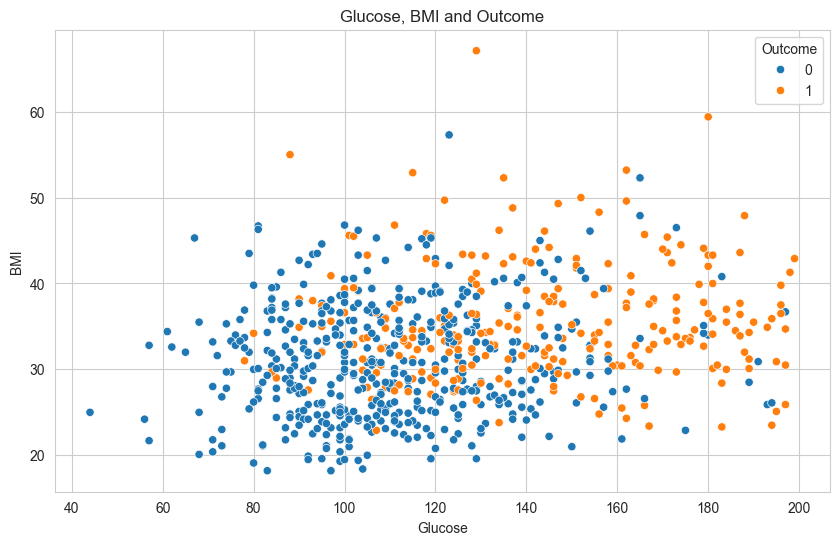

In [6]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="Glucose", y="BMI", hue="Outcome")
plt.title("Glucose, BMI and Outcome")
plt.show()


## 5. Tách feature, label, rồi chia tập học và tập kiểm tra

X là Glucose, BMI và Age. y là Outcome. 80% hàng để học, 20% hàng để kiểm tra. random_state = 42 giữ cách chia không đổi.


In [7]:
X = df[["Glucose", "BMI", "Age"]]
y = df["Outcome"]
print(X.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


(752, 3)


## 6. Huấn luyện

LogisticRegression(max_iter = 200) học bên trong thư viện, tối đa 200 vòng, và có thể dừng sớm. n_iter_ cho biết đã chạy bao nhiêu vòng.

Mô hình tính một số z, rồi đưa qua hàm sigmoid để ra xác suất từ 0 đến 1.

$$z = b + w_1 \times Glucose + w_2 \times BMI + w_3 \times Age$$

$$P = \frac{1}{1 + e^{-z}}$$

intercept_ là bias b. coef_ là ba weight.


In [8]:
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)
print("rounds =", model.n_iter_[0])
print("bias =", model.intercept_[0])
print("weight =", model.coef_[0])


rounds = 41
bias = -8.786610074348575
weight = [0.03411947 0.08551537 0.02964756]


## 7. Thử một người trong tập kiểm tra

predict_proba trả về hai số. Phần tử [0][1] là xác suất Outcome = 1.

Ngưỡng là 0.5. Xác suất lớn hơn hoặc bằng 0.5 thì gọi là Diabetes. Nhỏ hơn 0.5 thì gọi là No diabetes.

score là accuracy trên tập kiểm tra: tỷ lệ đoán đúng. Bài này khoảng 0.78, tức khoảng 78%.


In [9]:
person = X_test.iloc[[0]]
probability = model.predict_proba(person)[0][1]
label = "Diabetes" if probability >= 0.5 else "No diabetes"
real = "Diabetes" if y_test.iloc[0] == 1 else "No diabetes"

print(person)
print("Probability =", f"{probability:.4f}")
print("Prediction =", label)
print("Real =", real)
print("Accuracy =", round(model.score(X_test, y_test), 3))


     Glucose   BMI  Age
598    173.0  36.8   38
Probability = 0.8005
Prediction = Diabetes
Real = Diabetes
Accuracy = 0.781


## 8. Đọc kết quả

Người vừa in có Glucose = 173, BMI = 36.8, Age = 38. Xác suất khoảng 0.80, nên dự đoán là Diabetes. Nhãn thật cũng là Diabetes.

Accuracy khoảng 0.78 nghĩa là trên tập kiểm tra, khoảng 78 trong 100 người được gọi đúng. Phần còn lại là những người hai nhóm còn trộn trên biểu đồ: đường huyết và BMI chưa đủ để tách hết.

Insulin và SkinThickness vẫn chưa đưa vào X. Hai cột đó ghi 0 ở hàng trăm người. Nếu bỏ mọi hàng thiếu hai cột này, data từ 768 người chỉ còn khoảng 392. Muốn dùng chúng thì phải điền số thiếu, không nên xóa hết các hàng đó.
